In [2]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

In [2]:
df = pd.read_csv(
    "data/THIDDIAXL003_DIAmethodEval_SN20c4_Report_FM_crosslinking_plusDecoy_req.csv_annotated.csv.xz",
    compression="xz",
    low_memory=False,
)

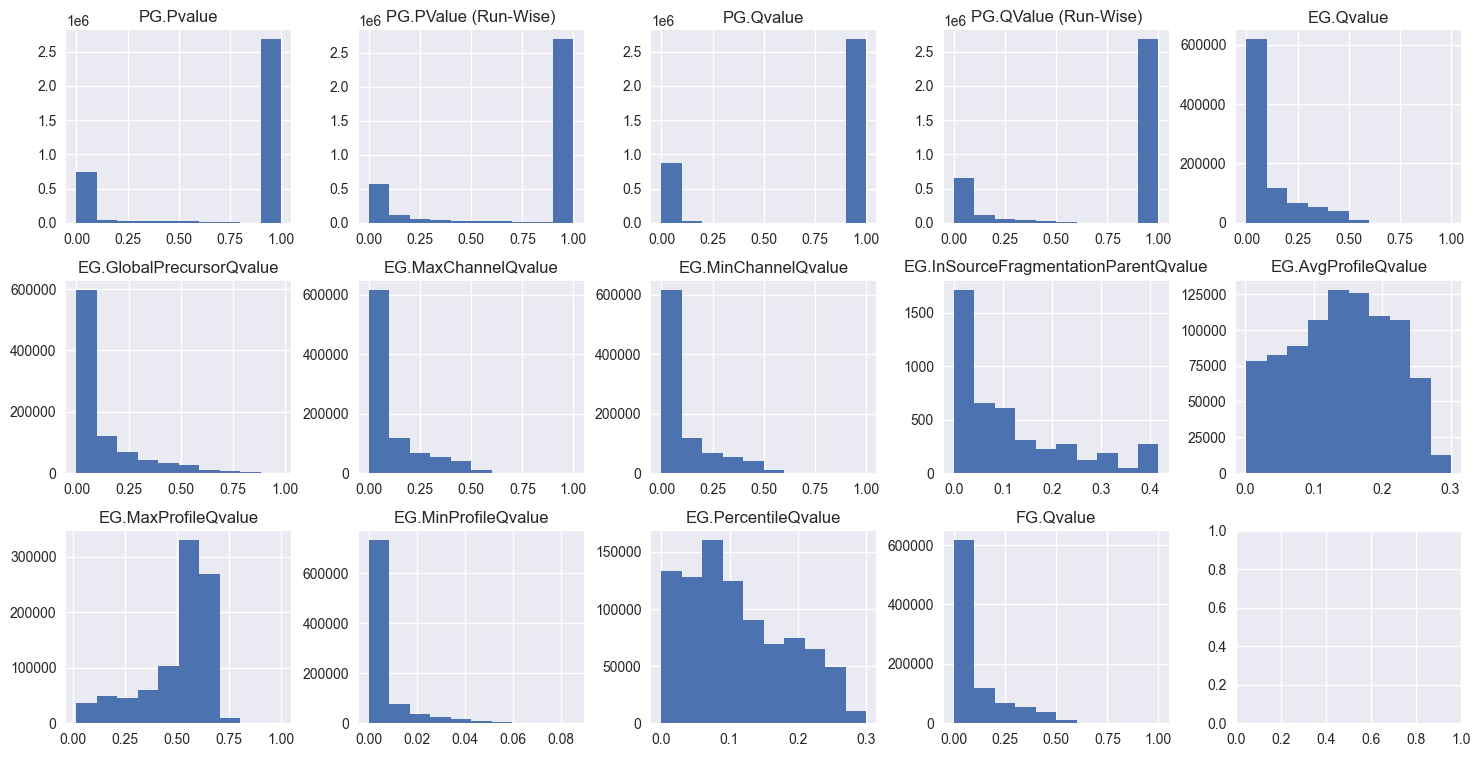

In [3]:
fig, ax = plt.subplots(3, 5, figsize=(18, 9))
df.hist("PG.Pvalue", bins=10, ax=ax[0, 0])
df.hist("PG.PValue (Run-Wise)", bins=10, ax=ax[0, 1])
df.hist("PG.Qvalue", bins=10, ax=ax[0, 2])
df.hist("PG.QValue (Run-Wise)", bins=10, ax=ax[0, 3])
df.hist("EG.Qvalue", bins=10, ax=ax[0, 4])
df.hist("EG.GlobalPrecursorQvalue", bins=10, ax=ax[1, 0])
df.hist("EG.MaxChannelQvalue", bins=10, ax=ax[1, 1])
df.hist("EG.MinChannelQvalue", bins=10, ax=ax[1, 2])
df.hist("EG.InSourceFragmentationParentQvalue", bins=10, ax=ax[1, 3])
df.hist("EG.AvgProfileQvalue", bins=10, ax=ax[1, 4])
df.hist("EG.MaxProfileQvalue", bins=10, ax=ax[2, 0])
df.hist("EG.MinProfileQvalue", bins=10, ax=ax[2, 1])
df.hist("EG.PercentileQvalue", bins=10, ax=ax[2, 2])
df.hist("FG.Qvalue", bins=10, ax=ax[2, 3]);

In [4]:
df = pd.read_csv(
    "data/THIDDIAXL003_DIAmethodEval_SN20c4_Report_FM_crosslinking_plusDecoy_req.csv_annotated.csv_grouped_by_residue_pair.csv",
    low_memory=False,
)

In [6]:
import pyXLMS
from pyXLMS.data import create_csm
from pyXLMS.parser.util import format_sequence
from pyXLMS.parser.util import get_bool_from_value
from tqdm import tqdm

from typing import List
from typing import Dict
from typing import Any
from typing import Literal

def read_csms(
    df: pd.DataFrame,
    score: Literal["EG.Cscore", "PP.CompositeRelativeMatchScore", "PP.CompositePartialCscore", "PP.UniScoreFull"]
) -> List[Dict[str, Any]]:
    csms = list()
    for i, row in tqdm(df.iterrows(), total=df.shape[0], desc="Reading CSMs..."):
        if score == "PP.CompositeRelativeMatchScore":
            score_a = float(row["PP.RelativeMatchScoreA"])
            score_b = float(row["PP.RelativeMatchScoreB"])
            score_csm = float(row["PP.CompositeRelativeMatchScore"])
        elif score == "PP.CompositePartialCscore":
            score_a = float(row["PP.PartialCscoreA"])
            score_b = float(row["PP.PartialCscoreB"])
            score_csm = float(row["PP.CompositePartialCscore"])
        elif score == "PP.UniScoreFull":
            score_a = float(row["PP.UniScoreAlpha"])
            score_b = float(row["PP.UniScoreBeta"])
            score_csm = float(row["PP.UniScoreFull"])
        else:
            score_a = float(row["EG.Cscore"])
            score_b = float(row["EG.Cscore"])
            score_csm = float(row["EG.Cscore"])
        csm = create_csm(
            peptide_a=format_sequence(row["PP.PeptideA"]),
            modifications_a=None,
            xl_position_peptide_a=int(row["PP.CrosslinkPositionPeptideA"]),
            proteins_a=str(row["PP.ProteinA"]).split(";"),
            xl_position_proteins_a=[int(pos) for pos in str(row["PP.CrosslinkPositionProteinA"]).split(";")],
            pep_position_proteins_a=[int(pos) for pos in str(row["PP.PeptidePositionProteinA"]).split(";")],
            score_a=score_a,
            decoy_a=get_bool_from_value(row["PP.IsDecoyA"]),
            peptide_b=format_sequence(row["PP.PeptideB"]),
            modifications_b=None,
            xl_position_peptide_b=int(row["PP.CrosslinkPositionPeptideB"]),
            proteins_b=str(row["PP.ProteinB"]).split(";"),
            xl_position_proteins_b=[int(pos) for pos in str(row["PP.CrosslinkPositionProteinB"]).split(";")],
            pep_position_proteins_b=[int(pos) for pos in str(row["PP.PeptidePositionProteinB"]).split(";")],
            score_b=score_b,
            decoy_b=get_bool_from_value(row["PP.IsDecoyB"]),
            score=score_csm,
            spectrum_file=f"{row['R.Condition'].strip()}:{row['R.FileName'].strip()}",
            scan_nr=int(row["PP.PseudoScanNumber"]),
            charge=int(row["FG.Charge"]),
            rt=None,
            im_cv=None,
        )
        csms.append(csm)
    return csms


def pipeline(csms: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    u = pyXLMS.transform.unique(csms)
    v = pyXLMS.transform.validate(u)
    t = pyXLMS.transform.targets_only(v)
    return t

In [8]:
df["R.Condition"].value_counts()

R.Condition
DIA12_CV48        14480
DIA12_CV486075       12
Name: count, dtype: int64

In [ ]:
cond1 = df[df["R.Condition"]=="DIA12_CV48"]
cond2 = df[df["R.Condition"]=="DIA12_CV486075"]

In [7]:
cscore = read_csms(df, score="EG.Cscore")
pcscore = read_csms(df, score="PP.CompositePartialCscore")
mscore = read_csms(df, score="PP.CompositeRelativeMatchScore")
uniscore = read_csms(df, score="PP.UniScoreFull")

Reading CSMs...: 100%|████████████████████████████████████████████████████████| 14492/14492 [00:01<00:00, 12655.40it/s]
